# 🚚 **Entregables**

**No olvide duplicar esta notebook para poder editar: File->Save a copy in Drive**

En este laboratorio, no es necesario redactar un informe en un documento separado. Por favor, complete todas las actividades requeridas dentro de esta notebook de Google Colab. Recuerde que una notebook le permite ingresar elementos de texto de manera similar a un procesador de documentos. Una vez finalizadas las actividades propuestas, deberá entregar lo siguiente en la plataforma:

1. Un archivo PDF generado en Google Colab desde el menú "Archivo" -> "Imprimir".

2. El enlace público de Google Colab. Para ello, vaya al botón de compartir y cambie la configuración de compartición a "Cualquier persona con el enlace".

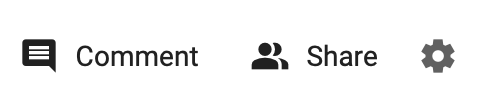

# 📔 **Resolución**
Una vez que la nota sea entregada, encontrarás la resolución en este link de notion:

https://www.notion.so/R-Churn-lab-classification-LogReg-with-and-without-GridSearchCV-154d05ccf4124959a2f7726d14dcd429?source=copy_link

Recuerda que existen varias formar de solucionar las actividades propuestas en los laboratorios. Toma la resolución entregada como referencia. En caso de que el link de resolución no esté público, solicita acceso en el mismo link de notion.|

# Predicción de pérdida de clientes en Empresas de Servicios de Telecomunicaciones (Churn)

Reducir las salidas y [deserciones de clientes](https://www.bain.com/insights/breaking-the-back-of-customer-churn/) se ha convertido en una alta prioridad para la mayoría de los proveedores de servicios de comunicaciones a medida que los mercados maduran y la competencia se intensifica.




En este documento usaremos una base de datos de una empresa de telecomunicaciones anónima [disponibilizada por IBM](https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv).

El principal objetivo es crear un model de aprendizaje automático basado Regresión Logística (similar al propuesto [aquí con SVM](https://github.com/mmcuri/ds_handson/blob/master/Telecom_Churn_Prediction.ipynb)) para predecir la pérdida o salida de clientes en una empresa de telecomunicaciones.


## Librerías

Importamos varias bibliotecas y módulos útiles para el análisis de datos y el aprendizaje automático en Python. A continuación se describe cada uno de ellos:

- `pandas as pd`: Importa la biblioteca Pandas y la renombra como "pd". Pandas es una biblioteca popular utilizada para la manipulación y análisis de datos en Python.

- `numpy as np`: Importa la biblioteca NumPy y la renombra como "np". NumPy es una biblioteca de Python utilizada para realizar operaciones matemáticas en matrices y vectores.

- `matplotlib.pyplot as plt`: Importa la biblioteca Matplotlib y el módulo pyplot y lo renombra como "plt". Matplotlib es una biblioteca utilizada para la visualización de datos en Python.

- `from sklearn.metrics import classification_report`: Importa la función classification_report desde el módulo metrics de la biblioteca scikit-learn. classification_report es una función que calcula y muestra un informe de clasificación detallado para un modelo de clasificación.

- `from sklearn.metrics import confusion_matrix`: Importa la función confusion_matrix desde el módulo metrics de la biblioteca scikit-learn. confusion_matrix es una función que calcula y muestra la matriz de confusión para un modelo de clasificación.

- `from sklearn.metrics import accuracy_score`: Importa la función accuracy_score desde el módulo metrics de la biblioteca scikit-learn. accuracy_score es una función que calcula y muestra la precisión de un modelo de clasificación.

- `from sklearn.metrics import roc_auc_score`: Importa la función roc_auc_score desde el módulo metrics de la biblioteca scikit-learn. roc_auc_score es una función que calcula el área bajo la curva ROC (AUC) para un modelo de clasificación.

- `from sklearn.preprocessing import StandardScaler, LabelEncoder`: Importa las clases StandardScaler y LabelEncoder desde el módulo preprocessing de la biblioteca scikit-learn. StandardScaler es una clase utilizada para estandarizar los datos y LabelEncoder es una clase utilizada para codificar las etiquetas de clase en números enteros.

- `from sklearn.model_selection import train_test_split`: Importa la función train_test_split desde el módulo model_selection de la biblioteca scikit-learn. train_test_split es una función que divide los datos en conjuntos de entrenamiento y prueba para su uso en el modelado predictivo.

En resumen, este código importa varias bibliotecas y módulos que son útiles para el análisis de datos y el aprendizaje automático en Python.


In [1]:
# importing libraries
import pandas as pd #excel sofisticado
import numpy as np #matlab
import matplotlib.pyplot as plt #plots
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split


## Base de datos

Este conjunto de datos contiene un total de 7043 clientes y 21 características de los mismos. De las entradas, 5174 son clientes activos y 1869 son clientes que la empresa ha perdido. Observe que el conjunto de datos está desbalanceado pues por cada cliente perdido existe casi 3 clientes activos. La variable de salida para nuestro modelo de machine learning será `Churn`.

In [2]:
# importamos dataset
DATA_PATH = "https://raw.githubusercontent.com/mtgca/datasets_public/main/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(DATA_PATH)
#print(df)
# vemos las primeras 5 filas
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### *Detalles de la base de datos*

*	`customerID` - Custumer unique identifier
*	`gender` - Customer gender - ['Female' 'Male']
*	`SeniorCitizen` - Elderly or retired person, a senior citizen is someone who has at least attained the age of 60 of 65 years
*	`Partner` - - ['No' 'Yes']
*	`Dependents` - If customer has dependents - ['No' 'Yes']
*	`Tenure` - Customer lifespan (in months)
*	`PhoneService` - - ['No' 'Yes']
*	`MultipleLines` - - ['No' 'No phone service' 'Yes']
*	`InternetService` - - ['No' 'No internet service' 'Yes']
*	`OnlineSecurity` - - ['No' 'No internet service' 'Yes']
*	`OnlineBackup` - - ['No' 'No internet service' 'Yes']
*	`DeviceProtection` - - ['No' 'No internet service' 'Yes']
*	`TechSupport` - - ['No' 'No internet service' 'Yes']
*	`StreamingTV` - - ['No' 'No internet service' 'Yes']
*	`StreamingMovies` -  - ['No' 'No internet service' 'Yes']
*	`Contract` - Type of contract - ['Month-to-month' 'One year' 'Two year']
*	`PaperlessBilling` - - ['No' 'Yes']
*	`PaymentMethod` - payment method - ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']
*	`MonthlyCharges` - Monthly Recurring Charges
*	`TotalCharges` - Life time value
*	`Churn` - Churn value, the targer vector - ['No' 'Yes']





### *Limpieza del Dataset*

El código presenta una serie de operaciones de preprocesamiento de datos en una base de datos que contiene información sobre clientes de una compañía, incluyendo su género, edad, servicios contratados, pagos realizados, entre otros.

En primer lugar, se define la función get_df_size para imprimir el número de atributos y entradas de la base de datos.

Luego, se reemplazan los valores en blanco por NaN para facilitar el manejo de valores faltantes en la base de datos.

A continuación, se reemplazan los valores faltantes en la columna 'TotalCharges' por la mediana de esa columna y se convierte esa columna al tipo numérico.

Después, se elimina la columna 'customerID' ya que no es una característica relevante.

A continuación, se codifican las características binarias en 0's y 1's usando LabelEncoder y se imprimen las categorías correspondientes a cada una de estas características.



**¿Por qué One-Hot Encoding?**

Cuando tenemos variables categóricas (por ejemplo, Color = {Rojo, Verde, Azul}), necesitamos convertirlas en valores numéricos para que los modelos puedan procesarlas. Hay dos enfoques comunes:

1. Label Encoding:
Asigna un número entero a cada categoría

(Rojo = 0, Verde = 1, Azul = 2).

El problema es que el modelo interpreta estos valores como si hubiera una relación de orden —por ejemplo, que Azul > Verde > Rojo—, algo que no tiene sentido en variables nominales. Esto introduce una falsa relación ordinal entre categorías.

2. One-Hot Encoding:
Crea una columna binaria para cada categoría. Por ejemplo:

Rojo → (1, 0, 0), Verde → (0, 1, 0), Azul → (0, 0, 1).

Así, cada categoría se representa como un vector independiente, sin orden ni jerarquía.

En la figura:

* A la izquierda (Label Encoding), las categorías están sobre una línea, implicando un orden.

* A la derecha (One-Hot Encoding), cada categoría ocupa un eje distinto, mostrando independencia.

👉 Implicación:
El one-hot encoding evita que el modelo asuma relaciones inexistentes y garantiza un tratamiento justo entre categorías puramente nominales.

⚠️ Desventajas del One-Hot Encoding:
* Incrementa la dimensionalidad del dataset (una columna por categoría).
* Puede generar matrices muy dispersas (muchos ceros).
* Es menos eficiente para variables con muchas categorías (“high cardinality”).
* Puede aumentar el tiempo de entrenamiento y el uso de memoria en modelos grandes.

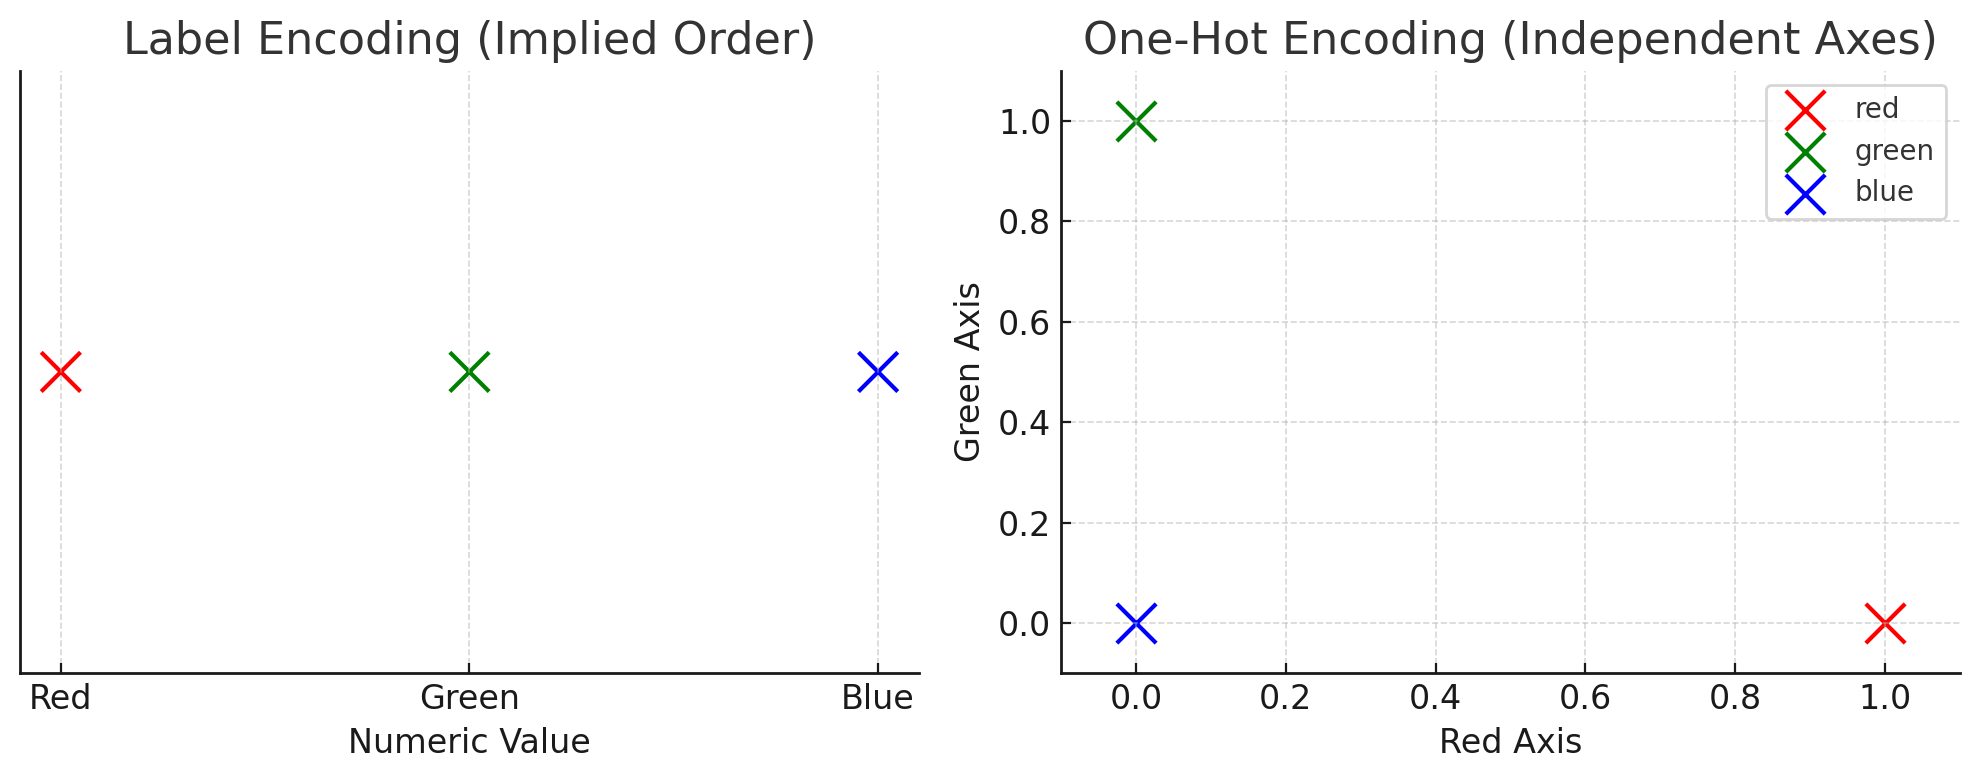

In [3]:
def get_df_size(df, header='Dataset dimensions'):
  print(header,
        '\n# Attributes: ', df.shape[1],
        '\n# Entries: ', df.shape[0],'\n')

get_df_size(df)

#df.info()

# reemplaza valores en blanco por NaN
df_clean = df.replace(r'^\s*$', np.nan, regex=True)

# Convert 'TotalCharges' to numeric before calculating the median.
# errors='coerce' will handle any non-numeric values by setting them to NaN.
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

# reemplaza valores faltantes en TotalCharges por la mediana de TotalCharges.
total_charges_median = df_clean.TotalCharges.median()
df_clean['TotalCharges'].fillna(total_charges_median, inplace=True)
df_clean['TotalCharges'] = df_clean['TotalCharges'].apply(pd.to_numeric)

#CustomerID lo retiramos porque no es una característica
df_clean = df_clean.drop('customerID', axis=1)
df_clean.describe()

print("Churn No Instances: ", df_clean[df_clean['Churn'] == 'No'].shape[0])
print("Churn Yes Instances: ", df_clean[df_clean['Churn'] == 'Yes'].shape[0])

binary_feat = df_clean.nunique()[df_clean.nunique() == 2].keys().tolist()
numeric_feat = [col for col in df_clean.select_dtypes(['float','int']).columns.tolist() if col not in binary_feat]
categorical_feat = [ col for col in df_clean.select_dtypes('object').columns.to_list() if col not in binary_feat + numeric_feat ]
df_proc = df_clean.copy()
#Etiquetas para características binarias
le = LabelEncoder()
for i in binary_feat:
  df_proc[i] = le.fit_transform(df_proc[i])
  print(i, '\n', np.unique(df_proc[i].values))
#Dummy variables
df_proc = pd.get_dummies(df_proc, columns=categorical_feat)
get_df_size(df, header='Original dataset:')
get_df_size(df_proc, header='Processed dataset:')
df_proc.head()


Dataset dimensions 
# Attributes:  21 
# Entries:  7043 



C:\Users\evely\AppData\Local\Temp\ipykernel_12332\2470922283.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['TotalCharges'].fillna(total_charges_median, inplace=True)


Churn No Instances:  5174
Churn Yes Instances:  1869
gender 
 [0 1]
SeniorCitizen 
 [0 1]
Partner 
 [0 1]
Dependents 
 [0 1]
PhoneService 
 [0 1]
PaperlessBilling 
 [0 1]
Churn 
 [0 1]
Original dataset: 
# Attributes:  21 
# Entries:  7043 

Processed dataset: 
# Attributes:  41 
# Entries:  7043 



,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,True,False,False,True,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,True,False,False,False,True,False,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,True,False,False,True,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,True,False,True,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,True,False,False,True,False,False,False,False,True,False


### *División en conjunto de entrenamiento y test*

En el código, se divide el conjunto de datos df_proc en características y variable objetivo X e y, respectivamente. Luego, se realiza una división de los datos en conjuntos de entrenamiento y prueba utilizando la función train_test_split de scikit-learn. Los conjuntos de entrenamiento y prueba se almacenan en X_train, X_test, y_train y y_test. La división se realiza de manera estratificada para asegurar que la proporción de instancias positivas y negativas en la variable objetivo se mantenga en ambos conjuntos. Se utiliza una proporción de 80/20 para los conjuntos de entrenamiento y prueba, respectivamente, y se fija una semilla aleatoria (random_state) en 42 para asegurar que los resultados sean reproducibles.

In [4]:
# dividimos df_proc en características y salida
X=df_proc.drop('Churn', axis=1)
y=df_proc['Churn']

# Dividimos el conjunto de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

### *Balanceo de datos*

Este código realiza el submuestreo (undersampling) de un conjunto de datos desbalanceado en términos de la variable objetivo. El submuestreo se utiliza para abordar el problema del desequilibrio de clases en el conjunto de datos, donde una o varias clases tienen muchas menos observaciones que las otras clases. En este caso, el modelo de aprendizaje automático puede estar sesgado hacia la clase mayoritaria, lo que puede resultar en un rendimiento deficiente en la clasificación de la clase minoritaria.

El submuestreo implica reducir el número de observaciones en la clase mayoritaria para equilibrar la distribución de las clases en el conjunto de datos. Esto puede mejorar el rendimiento del modelo en la clasificación de la clase minoritaria y reducir el sesgo hacia la clase mayoritaria.

La biblioteca imblearn se utiliza para realizar el submuestreo, y en este caso se importa la clase RandomUnderSampler. El objeto RandomUnderSampler se inicializa con random_state=1, lo que garantiza que los resultados serán reproducibles.

Luego, el submuestreo se realiza en el conjunto de entrenamiento (X_train, y_train) mediante el método fit_resample del objeto rus. Los datos submuestreados se almacenan en X_train_rus y y_train_rus.

Para evaluar el efecto del submuestreo, se utiliza la función get_df_size, que devuelve el tamaño del conjunto de datos. Primero se imprime el tamaño del conjunto de entrenamiento original (X_train, y_train) antes del submuestreo, y luego se imprime el tamaño del conjunto submuestreado (X_train_rus, y_train_rus) después de aplicar el submuestreo.

Finalmente, se utiliza la función np.unique para verificar que las categorías de la variable objetivo (y_train_rus) estén balanceadas. La función devuelve una tupla que contiene las categorías únicas y el número de instancias en cada categoría. Al utilizar return_counts=True, se garantiza que se devuelvan los recuentos de las categorías.

In [6]:
!pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imb

In [7]:
# submuestreo -> under sampling
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=1)
X_train_undersampled, y_train_undersampled = rus.fit_resample(X_train, y_train)
get_df_size(X_train, header='Before balancing:')
get_df_size(X_train_undersampled, header='After balancing:')

# verificamos que las categorias estén balanceadas
np.unique(y_train_undersampled, return_counts=True)


Before balancing: 
# Attributes:  40 
# Entries:  5634 

After balancing: 
# Attributes:  40 
# Entries:  2990 



(array([0, 1]), array([1495, 1495]))

## Modelo de Machine Learning

Este código construye un modelo de regresión logística para un conjunto de datos y lo evalúa en un conjunto de datos de prueba y de entrenamiento.

Primero, se define una tubería (pipeline) que encadena tres pasos:

PolynomialFeatures(degree=2): Crea una matriz de características polinómicas de grado 2 a partir de las características originales.
StandardScaler(): Estandariza las características.
LogisticRegression(max_iter=20000, penalty='l2', C=1/lambda_value): Ajusta un modelo de regresión logística a los datos, utilizando una regularización L2 (Ridge) y un parámetro de regularización C inversamente proporcional a lambda_value.
Luego, el modelo se entrena en un conjunto de datos de entrenamiento (X_train_undersampled e y_train_undersampled) utilizando el método fit.

A continuación, el modelo se evalúa en un conjunto de datos de prueba (X_test e y_test). Las predicciones se obtienen con el método predict y se calcula la precisión (accuracy) utilizando metrics.accuracy_score. La precisión en el conjunto de datos de prueba se almacena en la variable acc_test y se imprime en pantalla.

Finalmente, se evalúa el modelo en el conjunto de datos de entrenamiento (X_train_undersampled e y_train_undersampled) y se almacena la precisión en la variable acc_train, que también se imprime en pantalla.

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
import sklearn.metrics as metrics

lambda_value = 1
model_logreg =  Pipeline([
                ('polynomial_features', PolynomialFeatures(degree=2)), #no cambiar
                ('scaler', StandardScaler()),
                ('logistic_regression', LogisticRegression(max_iter=20000, penalty='l2', C=1/lambda_value))
 ])

# training
model_logreg.fit(X_train_undersampled, y_train_undersampled)

# evaluation on test set
pred_test = model_logreg.predict(X_test)
acc_test = metrics.accuracy_score(y_test, pred_test)
print("Accuracy on test set Logistic Regression: ", acc_test)
# evaluation on training set
pred_train = model_logreg.predict(X_train_undersampled)
acc_train = metrics.accuracy_score(y_train_undersampled, pred_train)
print("Accuracy on training set Logistic Regression: ", acc_train)

Accuracy on test set Logistic Regression:  0.7345635202271115
Accuracy on training set Logistic Regression:  0.7963210702341137


## ✅ Actividad 1

El objetivo de esta actividad es generar un gráfico donde el eje X represente el hiperparámetro de regularización lambda (`lambda_value`) y el eje Y muestre el **recall**. El recall es una métrica entre 0 y 1, donde 1 indica el mejor rendimiento (0% falsos negativos).

El gráfico deberá incluir el recall tanto para el conjunto de entrenamiento como para el conjunto de validación. Utilice los siguientes valores de lambda para el eje X: `[1e-4, 1e-3, 1e-2, 0.1, 1, 10, 100, 1e3, 1e4]`. Configure el eje X con una escala logarítmica para una mejor visualización.

A partir del gráfico, identifique el valor óptimo de lambda. Para ello, utilice GridSearchCV con k=5 folds.

Finalmente, evalúe el modelo optimizado (es decir, aquel con el `lambda_value` que mostró el mejor rendimiento en el conjunto de validación) en el conjunto de prueba, reportando tanto el accuracy como el recall. Tenga en cuenta que esta actividad podría **tardar en ejecutarse**.

¿Por qué considera que el recall es una métrica más adecuada para este problema? Analice la importancia de reducir los falsos negativos en la predicción de churn.

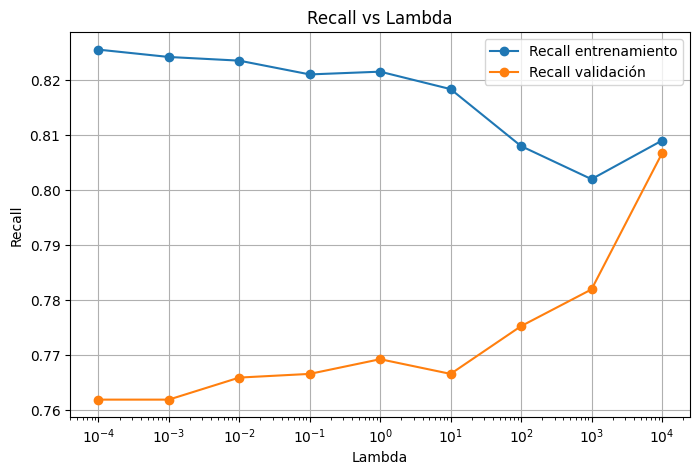

Mejor lambda: 10000.0
Mejor recall validación: 0.8066889632107024
Accuracy test Actividad 1: 0.7317246273953159
Recall test Actividad 1: 0.7967914438502673
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.80      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.73      0.75      1409



In [11]:
# Importar librerías necesarias para el pipeline y la búsqueda de hiperparámetros
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import recall_score, accuracy_score, classification_report
import matplotlib.pyplot as plt
import numpy as np

# Definir los valores de lambda a evaluar para regularización
lambda_values = [1e-4, 1e-3, 1e-2, 0.1, 1, 10, 100, 1e3, 1e4]

# Convertir los valores de lambda a C porque sklearn usa C = 1/lambda
C_values = [1/l for l in lambda_values]

# Crear el pipeline con transformación polinómica, escalamiento y regresión logística
pipeline_act1 = Pipeline([
    ('polynomial_features', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('logistic_regression', LogisticRegression(max_iter=20000, penalty='l2'))
])

# Definir los valores de C que serán evaluados en el modelo
param_grid = {
    'logistic_regression__C': C_values
}

# Configurar GridSearchCV usando recall como métrica principal
grid_search = GridSearchCV(
    estimator=pipeline_act1,
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    return_train_score=True,
    n_jobs=-1
)

# Entrenar el modelo con los datos balanceados por undersampling
grid_search.fit(X_train_undersampled, y_train_undersampled)

# Obtener los valores promedio de recall en entrenamiento
train_recall = grid_search.cv_results_['mean_train_score']

# Obtener los valores promedio de recall en validación
val_recall = grid_search.cv_results_['mean_test_score']

# Crear la figura para graficar los resultados
plt.figure(figsize=(8,5))
plt.plot(lambda_values, train_recall, marker='o', label='Recall entrenamiento')
plt.plot(lambda_values, val_recall, marker='o', label='Recall validación')
plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('Recall')
plt.title('Recall vs Lambda')
plt.legend()
plt.grid(True)
plt.show()

# Obtener el mejor valor de C encontrado por GridSearchCV
best_C = grid_search.best_params_['logistic_regression__C']

# Convertir el mejor C al valor equivalente de lambda
best_lambda = 1 / best_C

print("Mejor lambda:", best_lambda)
print("Mejor recall validación:", grid_search.best_score_)

# Guardar el mejor modelo encontrado
best_model_act1 = grid_search.best_estimator_

# Realizar predicciones sobre el conjunto de prueba
y_pred_test_act1 = best_model_act1.predict(X_test)

# Calcular el accuracy del modelo en prueba
acc_act1 = accuracy_score(y_test, y_pred_test_act1)

# Calcular el recall del modelo en prueba
recall_act1 = recall_score(y_test, y_pred_test_act1)

print("Accuracy test Actividad 1:", acc_act1)
print("Recall test Actividad 1:", recall_act1)
print(classification_report(y_test, y_pred_test_act1))


### Evaluación del modelo - Actividad 1

El modelo optimizado corresponde al modelo con un valor de λ = 10000, ya que obtuvo el mejor desempeño en el conjunto de validación, alcanzando un recall de 0.8067. Al evaluar este modelo sobre el conjunto de prueba se obtuvo un accuracy de 0.7317 y un recall de 0.7968.

La gráfica muestra que, a medida que aumenta λ, el recall de validación tiende a mejorar, alcanzando su valor máximo para λ = 10000. Además, la diferencia entre el recall de entrenamiento y el de validación disminuye para este valor, lo que sugiere una mejor capacidad de generalización y un menor riesgo de overfitting.

El recall es la métrica más adecuada para este problema porque el objetivo principal es identificar correctamente a los clientes que abandonarán el servicio (churn). En este contexto, un falso negativo ocurre cuando el modelo predice que un cliente permanecerá en la empresa, cuando en realidad sí abandonará el servicio.

Reducir los falsos negativos es especialmente importante porque estos clientes no serían identificados para recibir acciones de retención, como promociones, descuentos o atención personalizada. Como consecuencia, la empresa perdería clientes que podrían haberse retenido mediante una intervención oportuna. Por esta razón, resulta más relevante maximizar el recall que únicamente optimizar el accuracy, ya que detectar la mayor cantidad posible de clientes con riesgo de churn genera un mayor beneficio para el negocio.


## ✅ Actividad 2 Tratamiento del Desbalance de Clases mediante SMOTE y Pesos de Clase

Implemente un pipeline de scikit-learn que aborde el desbalance de clases utilizando dos técnicas simultáneamente:

1. **Sobremuestreo (Oversampling)**: Aplique la técnica SMOTE (`imblearn.over_sampling.SMOTE`) para sintéticamente generar muestras de la clase minoritaria.

2. **Pesos de Clase (Class Weights)**: Calcule y asigne pesos de clase (`sklearn.utils.class_weight.compute_class_weight`) al modelo de Regresión Logística para penalizar errores en la clase minoritaria.

Para esta actividad, utilice el conjunto de datos completo y original (es decir, **sin aplicar el undersampling** realizado en la Actividad 1).

Evalúe el rendimiento del modelo resultante (accuracy) en el conjunto de prueba y compárelo con los resultados obtenidos en la Actividad 1 (que utilizó undersampling).


**Recursos:**

https://machinelearningmastery.com/smote-oversampling-for-imbalanced-classification/

https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html



Pesos de clase: {np.int64(0): np.float64(0.6805991785455424), np.int64(1): np.float64(1.8842809364548494)}
Accuracy test Actividad 2: 0.6153300212916962
Recall test Actividad 2: 0.9385026737967914
              precision    recall  f1-score   support

           0       0.96      0.50      0.66      1035
           1       0.40      0.94      0.56       374

    accuracy                           0.62      1409
   macro avg       0.68      0.72      0.61      1409
weighted avg       0.81      0.62      0.63      1409

Comparación:
Actividad 1 - Accuracy: 0.7317246273953159 Recall: 0.7967914438502673
Actividad 2 - Accuracy: 0.6153300212916962 Recall: 0.9385026737967914


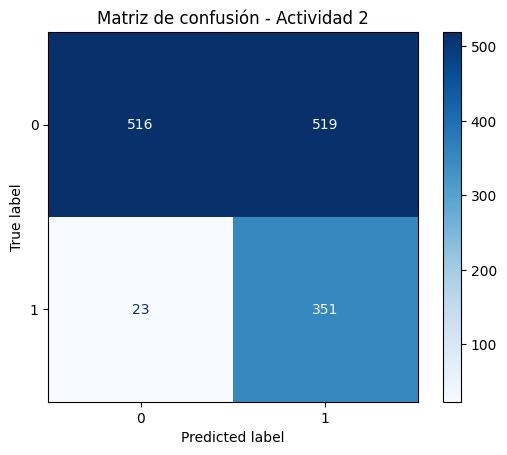

In [13]:
# Importar librerías necesarias
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Obtener las clases presentes en la variable objetivo
classes = np.unique(y_train)

# Calcular los pesos de clase para manejar el desbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

# Convertir los pesos de clase a un diccionario
class_weight_dict = dict(zip(classes, class_weights))

# Mostrar los pesos calculados para cada clase
print("Pesos de clase:", class_weight_dict)

# Crear el pipeline con transformación polinómica, escalamiento, SMOTE y regresión logística
pipeline_act2 = ImbPipeline([
    ('polynomial_features', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('logistic_regression', LogisticRegression(
        max_iter=20000,
        penalty='l2',
        C=best_C,
        class_weight=class_weight_dict
    ))
])

# Entrenar el modelo usando el conjunto de entrenamiento original
pipeline_act2.fit(X_train, y_train)

# Realizar predicciones sobre el conjunto de prueba
y_pred_test_act2 = pipeline_act2.predict(X_test)

# Calcular el accuracy del modelo en prueba
acc_act2 = accuracy_score(y_test, y_pred_test_act2)

# Calcular el recall del modelo en prueba
recall_act2 = recall_score(y_test, y_pred_test_act2)

print("Accuracy test Actividad 2:", acc_act2)
print("Recall test Actividad 2:", recall_act2)
print(classification_report(y_test, y_pred_test_act2))
print("Comparación:")

# Mostrar resultados de la Actividad 1
print("Actividad 1 - Accuracy:", acc_act1, "Recall:", recall_act1)

# Mostrar resultados de la Actividad 2
print("Actividad 2 - Accuracy:", acc_act2, "Recall:", recall_act2)


ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test_act2,
    cmap="Blues"
)

plt.title("Matriz de confusión - Actividad 2")
plt.show()

### Evaluación del modelo - Actividad 2

El modelo de la Actividad 2 fue evaluado utilizando el conjunto de prueba original, obteniendo un accuracy de 0.6153 y un recall de 0.9385. En comparación, el modelo de la Actividad 1 que utilizó undersampling, alcanzó un accuracy de 0.7317 y un recall de 0.7968.

| Modelo                              | Accuracy | Recall |
| ----------------------------------- | -------- | ------ |
| Actividad 1 (Undersampling)         | 0.7317   | 0.7968 |
| Actividad 2 (SMOTE + Class Weights) | 0.6153   | 0.9385 |

Se observa que el modelo de la Actividad 2 presenta una disminución en el accuracy respecto a la Actividad 1. Sin embargo, logra un incremento considerable en el recall, pasando de 79.68% a 93.85%. Esto indica que el modelo con SMOTE y pesos de clase es capaz de identificar una mayor proporción de clientes que efectivamente abandonarán el servicio.

La matriz de confusión muestra que únicamente 23 clientes con churn fueron clasificados incorrectamente como clientes que permanecerían en la empresa (falsos negativos), mientras que 351 clientes con churn fueron identificados correctamente. Este resultado es consistente con el alto valor de recall obtenido.

La reducción del accuracy se debe a que el modelo genera un mayor número de falsos positivos, clasificando como churn a algunos clientes que en realidad no abandonarán el servicio. No obstante, en problemas de predicción de churn suele ser preferible detectar la mayor cantidad posible de clientes en riesgo, incluso a costa de aumentar los falsos positivos, ya que el costo de perder un cliente suele ser mayor que el costo de realizar acciones de retención sobre un cliente que finalmente no abandona el servicio.

Por lo tanto, aunque la Actividad 2 presenta un accuracy menor, ofrece una mejor capacidad para identificar clientes con churn, lo cual puede resultar más valioso desde una perspectiva de negocio.


## ✅ Actividad 3: Combinando SMOTE, Pesos de Clase y PCA

Replique el enfoque de la Actividad 2 (utilizando SMOTE para sobremuestreo y pesos de clase para manejar el desbalance, sin undersampling), pero ahora **integrando PCA** en el pipeline.

El orden de los pasos en el pipeline es:

1.  `PolynomialFeatures`
2.  `StandardScaler`
3.  `PCA` (95%)
4.  `LogisticRegression` (con pesos de clase)

Utilice el mismo conjunto de datos completo y original que en la Actividad 2.

Evalúe el rendimiento del modelo resultante (accuracy, recall, y si lo desea, otras métricas relevantes) en el conjunto de prueba y compare los resultados con los obtenidos en las actividades anteriores.

¿Cómo afecta la reducción de dimensionalidad con PCA, en conjunto con SMOTE y pesos de clase, al rendimiento del modelo?

Accuracy test Actividad 3: 0.6132008516678495
Recall test Actividad 3: 0.9438502673796791
              precision    recall  f1-score   support

           0       0.96      0.49      0.65      1035
           1       0.40      0.94      0.56       374

    accuracy                           0.61      1409
   macro avg       0.68      0.72      0.61      1409
weighted avg       0.81      0.61      0.63      1409

Comparación final:

Actividad 1 - Undersampling
Accuracy: 0.7317246273953159 Recall: 0.7967914438502673

Actividad 2 - SMOTE + pesos de clase
Accuracy: 0.6153300212916962 Recall: 0.9385026737967914

Actividad 3 - SMOTE + pesos de clase + PCA
Accuracy: 0.6132008516678495 Recall: 0.9438502673796791

Número de componentes PCA: 114


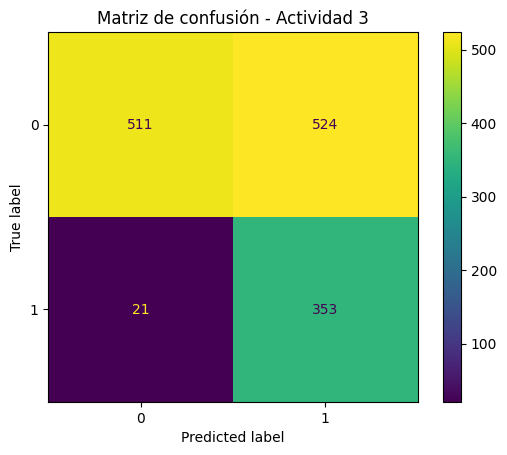

In [16]:
# Importar librerías necesarias para PCA y matriz de confusión
from sklearn.decomposition import PCA
from sklearn.metrics import ConfusionMatrixDisplay

# Crear el pipeline con PolynomialFeatures, escalamiento, PCA, SMOTE y regresión logística
pipeline_act3 = ImbPipeline([
    ('polynomial_features', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('smote', SMOTE(random_state=42)),
    ('logistic_regression', LogisticRegression(
        max_iter=20000,
        penalty='l2',
        C=best_C,
        class_weight=class_weight_dict
    ))
])

# Entrenar el modelo usando el conjunto completo y original
pipeline_act3.fit(X_train, y_train)

# Realizar predicciones sobre el conjunto de prueba
y_pred_test_act3 = pipeline_act3.predict(X_test)

# Calcular el accuracy del modelo en prueba
acc_act3 = accuracy_score(y_test, y_pred_test_act3)

# Calcular el recall del modelo en prueba
recall_act3 = recall_score(y_test, y_pred_test_act3)

print("Accuracy test Actividad 3:", acc_act3)
print("Recall test Actividad 3:", recall_act3)
print(classification_report(y_test, y_pred_test_act3))
print("Comparación final:")

# Mostrar resultados de la Actividad 1
print("\nActividad 1 - Undersampling")
print("Accuracy:", acc_act1, "Recall:", recall_act1)

# Mostrar resultados de la Actividad 2
print("\nActividad 2 - SMOTE + pesos de clase")
print("Accuracy:", acc_act2, "Recall:", recall_act2)

# Mostrar resultados de la Actividad 3
print("\nActividad 3 - SMOTE + pesos de clase + PCA")
print("Accuracy:", acc_act3, "Recall:", recall_act3)

# Mostrar cuántos componentes principales fueron retenidos por PCA
print("\nNúmero de componentes PCA:", pipeline_act3.named_steps['pca'].n_components_)

# Graficar la matriz de confusión de la Actividad 3
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test_act3
)

# Colocar título a la gráfica
plt.title("Matriz de confusión - Actividad 3")

# Mostrar la gráfica
plt.show()

### Evaluación del modelo - Actividad 3

El modelo de la Actividad 3, que combina SMOTE, pesos de clase y reducción de dimensionalidad mediante PCA, obtuvo un accuracy de 0.6132 y un recall de 0.9439 sobre el conjunto de prueba. Además, PCA redujo el espacio de características generado por PolynomialFeatures a 114 componentes principales, conservando el 95% de la varianza de los datos.

| Modelo                                     | Accuracy | Recall |
| ------------------------------------------ | -------- | ------ |
| Actividad 1 (Undersampling)                | 0.7317   | 0.7968 |
| Actividad 2 (SMOTE + Pesos de Clase)       | 0.6153   | 0.9385 |
| Actividad 3 (SMOTE + Pesos de Clase + PCA) | 0.6132   | 0.9439 |

Al comparar los resultados, se observa que la incorporación de PCA no produjo un impacto considerable sobre el desempeño del modelo. El accuracy disminuyó ligeramente de 0.6153 a 0.6132, mientras que el recall aumentó de 0.9385 a 0.9439. Esto indica que la reducción de dimensionalidad no afectó significativamente la capacidad predictiva del modelo.

La matriz de confusión muestra que el modelo identificó correctamente 353 de los 374 clientes que realizaron churn, generando únicamente 21 falsos negativos. En comparación con la Actividad 2, donde se registraron 23 falsos negativos, la incorporación de PCA permitió detectar ligeramente más clientes en riesgo de abandonar el servicio.

Estos resultados sugieren que PCA logró eliminar parte de la redundancia introducida por PolynomialFeatures sin perder información relevante para la clasificación. Sin embargo, la mejora obtenida es reducida, ya que los resultados de las Actividades 2 y 3 son muy similares. En ambos casos, el modelo prioriza la detección de clientes con churn, alcanzando valores de recall superiores al 93%, aunque a costa de un menor accuracy debido al incremento de falsos positivos.

En conclusión, la incorporación de PCA permitió reducir la dimensionalidad del problema manteniendo prácticamente el mismo desempeño que el modelo de la Actividad 2. Además, produjo una ligera mejora en el recall, reduciendo los falsos negativos, lo cual resulta beneficioso en problemas de predicción de churn donde es más importante identificar a los clientes que abandonarán el servicio que maximizar el accuracy general.


# ✅ Conclusiones

A lo largo de este taller se evaluaron diferentes estrategias para abordar el problema de predicción de churn en un conjunto de datos desbalanceado mediante modelos de Regresión Logística.

En la Actividad 1 se utilizó undersampling para balancear las clases y se optimizó el parámetro de regularización mediante validación cruzada. Este enfoque obtuvo el mejor accuracy (73.17%), pero presentó un recall de 79.68%, lo que significa que una proporción importante de clientes con churn no fue detectada.

En la Actividad 2 se empleó una combinación de SMOTE y pesos de clase utilizando el conjunto de datos completo. Esta estrategia permitió incrementar significativamente el recall hasta 93.85%, reduciendo considerablemente los falsos negativos. Sin embargo, esta mejora estuvo acompañada de una disminución en el accuracy (61.53%), debido al aumento de falsos positivos. A pesar de ello, en problemas de churn resulta más importante identificar correctamente a los clientes con riesgo de abandono que maximizar el accuracy general.

En la Actividad 3 se incorporó PCA para reducir la dimensionalidad de los datos después de aplicar Polynomial Features. PCA redujo el espacio de características a 114 componentes principales conservando el 95% de la varianza. Los resultados obtenidos fueron muy similares a los de la Actividad 2, alcanzando un accuracy de 61.32% y un recall de 94.39%. Esto indica que la reducción de dimensionalidad logró mantener prácticamente el mismo rendimiento predictivo, eliminando redundancia en las variables sin afectar significativamente la capacidad de detección de churn.

En general, los resultados muestran que las técnicas de manejo de desbalance tienen un impacto considerable en el desempeño del modelo. Mientras que el undersampling favoreció el accuracy, la combinación de SMOTE y pesos de clase permitió mejorar notablemente el recall, que es la métrica más relevante en este problema. Por esta razón, el modelo de la Actividad 3 puede considerarse el más adecuado, ya que logra el mayor recall, minimiza los falsos negativos y mantiene un desempeño similar al de la Actividad 2 utilizando una representación más compacta de los datos gracias a PCA.

Finalmente, se concluye que en problemas de predicción de churn no siempre el modelo con mayor accuracy es el más útil desde el punto de vista del negocio. La capacidad de identificar correctamente a los clientes que abandonarán el servicio tiene un valor estratégico mayor, ya que permite implementar acciones de retención oportunas y reducir la pérdida de clientes.
